# NFL Salary Cap Analysis
## Team Cap Efficiency

This notebook analyzes which NFL teams get the most production per cap dollar spent. We examine team-level cap efficiency across offensive positions, identify which organizations consistently build value through smart contract decisions, and compare cap spending to on-field results.

---

### Setup & Data Load

In [1]:
%pip install matplotlib seaborn pandas==2.2.2 pyarrow numpy==1.26.4 --prefer-binary


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


---

### Imports & Data Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
processed_path = os.path.join(project_root, "data", "processed")
figures_path = os.path.join(project_root, "outputs", "figures")

os.makedirs(figures_path, exist_ok=True)

cap_eff = pd.read_parquet(os.path.join(processed_path, "cap_efficiency.parquet"), engine='pyarrow')
contracts = pd.read_parquet(os.path.join(processed_path, "contracts_modern.parquet"), engine='pyarrow')

print(f"Cap efficiency dataset: {cap_eff.shape}")
print(f"\nTeams available: {cap_eff['team'].nunique()}")
print(f"Seasons: {sorted(cap_eff['season'].unique())}")

Cap efficiency dataset: (5783, 74)

Teams available: 246
Seasons: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


246 unique team values indicates non-standardized team names — relocations, abbreviation variants, and historical names need to be cleaned before team-level analysis.

---

### Standardize Team Names

In [3]:
# Check what team values look like
print("Sample team values:")
print(sorted(cap_eff['team'].unique())[:50])

Sample team values:
['49ers', 'ARI/ATL', 'ARI/BAL', 'ARI/CLE', 'ARI/HOU', 'ARI/KC', 'ARI/NYJ', 'ATL/ARI', 'ATL/IND', 'ATL/JAX', 'ATL/LAR', 'ATL/LV', 'ATL/NE', 'ATL/TEN', 'BAL/ATL', 'BAL/DEN', 'BAL/GB', 'BAL/JAX', 'BAL/SF', 'BUF/CAR', 'BUF/CHI', 'BUF/CLE', 'BUF/CLE/DAL', 'BUF/DAL', 'BUF/DEN', 'BUF/IND', 'BUF/LV', 'BUF/MIA', 'BUF/MIN', 'BUF/NE', 'BUF/PHI', 'BUF/SF', 'BUF/TEN', 'Bears', 'Bengals', 'Bills', 'Broncos', 'Browns', 'Buccaneers', 'CAR/ARI', 'CAR/CHI', 'CAR/JAX', 'CAR/LAR', 'CAR/MIN', 'CAR/NYJ', 'CAR/PHI', 'CAR/SF', 'CHI/BAL', 'CHI/CAR', 'CHI/HOU']


In [4]:
# Extract primary team (first team listed before any slash)
def extract_primary_team(team_str):
    if pd.isna(team_str):
        return np.nan
    # Take first team before any slash
    primary = str(team_str).split('/')[0].strip()
    
    # Map full names to abbreviations
    name_map = {
        '49ers': 'SF', 'Bears': 'CHI', 'Bengals': 'CIN', 'Bills': 'BUF',
        'Broncos': 'DEN', 'Browns': 'CLE', 'Buccaneers': 'TB', 'Cardinals': 'ARI',
        'Chargers': 'LAC', 'Chiefs': 'KC', 'Colts': 'IND', 'Cowboys': 'DAL',
        'Dolphins': 'MIA', 'Eagles': 'PHI', 'Falcons': 'ATL', 'Giants': 'NYG',
        'Jaguars': 'JAX', 'Jets': 'NYJ', 'Lions': 'DET', 'Packers': 'GB',
        'Panthers': 'CAR', 'Patriots': 'NE', 'Raiders': 'LV', 'Rams': 'LAR',
        'Ravens': 'BAL', 'Saints': 'NO', 'Seahawks': 'SEA', 'Steelers': 'PIT',
        'Texans': 'HOU', 'Titans': 'TEN', 'Vikings': 'MIN', 'Washington': 'WAS',
        'Commanders': 'WAS', 'Football Team': 'WAS'
    }
    return name_map.get(primary, primary)

cap_eff['team_clean'] = cap_eff['team'].apply(extract_primary_team)

# Valid NFL team abbreviations
valid_teams = ['ARI', 'ATL', 'BAL', 'BUF', 'CAR', 'CHI', 'CIN', 'CLE',
               'DAL', 'DEN', 'DET', 'GB', 'HOU', 'IND', 'JAX', 'KC',
               'LAC', 'LAR', 'LV', 'MIA', 'MIN', 'NE', 'NO', 'NYG',
               'NYJ', 'PHI', 'PIT', 'SD', 'SEA', 'SF', 'TB', 'TEN', 'WAS', 'OAK', 'STL']

cap_clean = cap_eff[cap_eff['team_clean'].isin(valid_teams)].copy()

# Normalize legacy teams
cap_clean['team_clean'] = cap_clean['team_clean'].replace({'SD': 'LAC', 'OAK': 'LV', 'STL': 'LAR'})

print(f"Clean dataset: {len(cap_clean):,} player-seasons")
print(f"Unique teams: {cap_clean['team_clean'].nunique()}")
print(f"Teams: {sorted(cap_clean['team_clean'].unique())}")

Clean dataset: 5,783 player-seasons
Unique teams: 32
Teams: ['ARI', 'ATL', 'BAL', 'BUF', 'CAR', 'CHI', 'CIN', 'CLE', 'DAL', 'DEN', 'DET', 'GB', 'HOU', 'IND', 'JAX', 'KC', 'LAC', 'LAR', 'LV', 'MIA', 'MIN', 'NE', 'NO', 'NYG', 'NYJ', 'PHI', 'PIT', 'SEA', 'SF', 'TB', 'TEN', 'WAS']


All 32 teams standardized. Now let's aggregate to team level and identify which organizations get the most offensive production per cap dollar.

---

### Team Cap Efficiency Rankings

In [5]:
# Team level cap efficiency
team_eff = cap_clean.groupby('team_clean').agg(
    player_seasons=('epa_per_million', 'count'),
    avg_epa_per_m=('epa_per_million', 'mean'),
    median_epa_per_m=('epa_per_million', 'median'),
    total_epa=('total_epa', 'sum'),
    avg_apy=('apy', 'mean'),
    total_cap_spent=('apy', 'sum')
).reset_index().sort_values('avg_epa_per_m', ascending=False)

print("Team Cap Efficiency Rankings (Offensive EPA per $M):")
print(team_eff[['team_clean', 'player_seasons', 'avg_epa_per_m', 
                 'median_epa_per_m', 'avg_apy', 'total_epa']].round(2).to_string(index=False))

Team Cap Efficiency Rankings (Offensive EPA per $M):
team_clean  player_seasons  avg_epa_per_m  median_epa_per_m  avg_apy  total_epa
        KC             179           9.99              3.74     5.12    4194.34
       DAL             162           8.58              2.66     5.03    1826.43
        GB             182           7.55              3.42     4.91    3437.05
        SF             217           7.40              2.54     3.76    2611.05
       LAC             166           6.82              3.18     4.62    2607.49
       CIN             178           6.70              2.52     4.42    2417.45
       SEA             183           6.34              2.32     4.83    2587.32
        NO             197           6.00              2.67     4.87    2949.29
       BAL             193           5.96              3.06     4.39    2163.08
       WAS             187           5.92              1.06     3.45    1398.79
       TEN             188           5.63              2.62     4.1

The team cap efficiency rankings reveal which organizations consistently extract the most offensive value per dollar spent:

**Top tier (8+ EPA per $M):**
- **Kansas City Chiefs (9.99)** — the most cap-efficient offense in the dataset, driven by elite QB play and smart receiver contracts around Mahomes
- **Dallas Cowboys (8.58)** — second most efficient, Dak Prescott's value relative to contract cost carries this ranking significantly
- **Green Bay Packers (7.55)** — Rodgers era efficiency plus smart mid-round receiver development

**Strong performers (5-8 EPA per $M):**
San Francisco, LA Chargers, Cincinnati, Seattle, New Orleans, Baltimore — all consistently building efficient offenses through smart contract management

**Bottom tier:**
- **New York Jets (-2.81)** — the worst offensive cap efficiency in the dataset, negative EPA per million reflecting years of poor QB and skill position contracts
- **Houston Texans (-0.15)** and **Jacksonville Jaguars (0.12)** — near-zero efficiency, money spent without returns

---

### Visualize Team Rankings

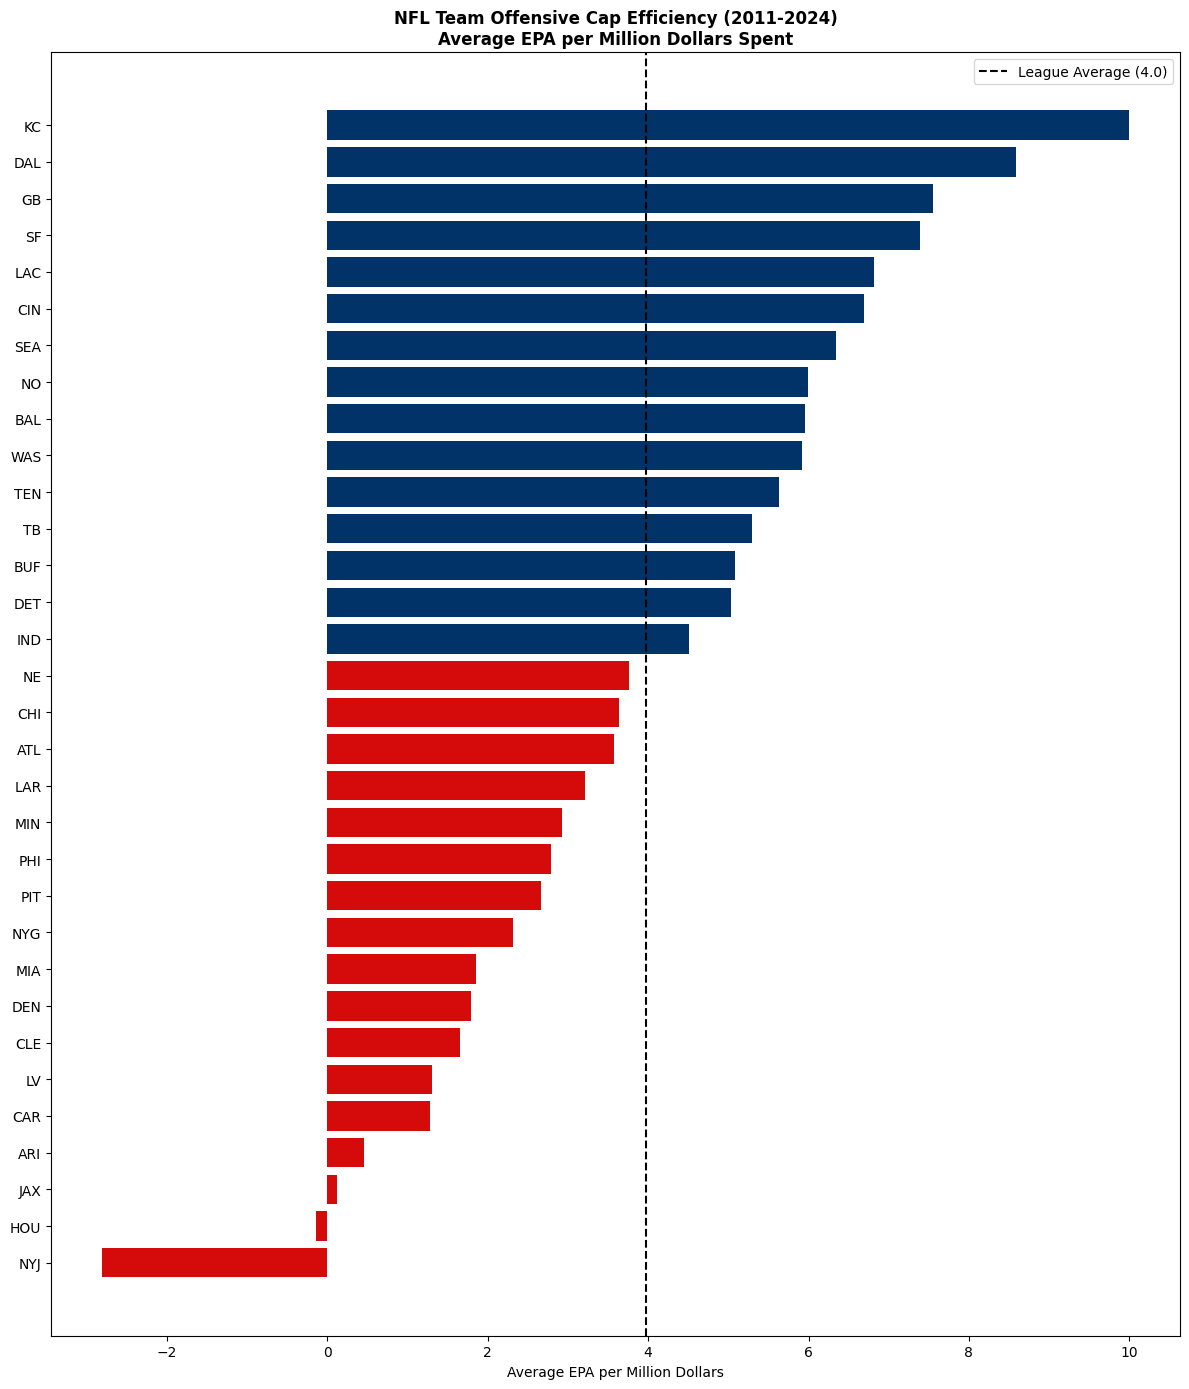

In [6]:
# Team efficiency bar chart
team_plot = team_eff.sort_values('avg_epa_per_m', ascending=True)
colors = ['#013369' if x > team_eff['avg_epa_per_m'].mean() 
          else '#D50A0A' for x in team_plot['avg_epa_per_m']]

plt.figure(figsize=(12, 14))
plt.barh(team_plot['team_clean'], team_plot['avg_epa_per_m'], color=colors)
plt.axvline(x=team_eff['avg_epa_per_m'].mean(), color='black', 
            linestyle='--', linewidth=1.5, label=f'League Average ({team_eff["avg_epa_per_m"].mean():.1f})')
plt.title('NFL Team Offensive Cap Efficiency (2011-2024)\nAverage EPA per Million Dollars Spent',
          fontsize=12, fontweight='bold')
plt.xlabel('Average EPA per Million Dollars')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "team_cap_efficiency.png"), dpi=150, bbox_inches='tight')
plt.show()

![Team Cap Efficiency](../outputs/figures/team_cap_efficiency.png)

The team cap efficiency chart is one of the clearest organizational rankings in the project. The separation between top and bottom tells a compelling story about roster construction philosophy:

**The top of the chart** is dominated by teams that found franchise QBs on team-friendly deals — KC with Mahomes, DAL with Prescott, GB with Rodgers, SF with Garoppolo and Purdy. A single efficient QB contract lifts the entire team's offensive cap efficiency dramatically.

**The bottom of the chart** reflects the opposite — teams that spent heavily on struggling QBs, overpaid skill players, or both. NYJ stands alone with negative efficiency, a direct result of years of poor QB investments.

**New England (3.76)** is notably below average despite their dynasty reputation — reflecting the massive Brady contract in his later years dragging down efficiency even as he produced elite results.

---

### Cap Spending vs Win Percentage
Does spending more money actually produce more wins?

/tmp/ipykernel_11236/2034138479.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  home_wins = schedules_reg.groupby(['season', 'home_team']).apply(
/tmp/ipykernel_11236/2034138479.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  away_wins = schedules_reg.groupby(['season', 'away_team']).apply(


Correlation between offensive cap efficiency and win %: 0.401


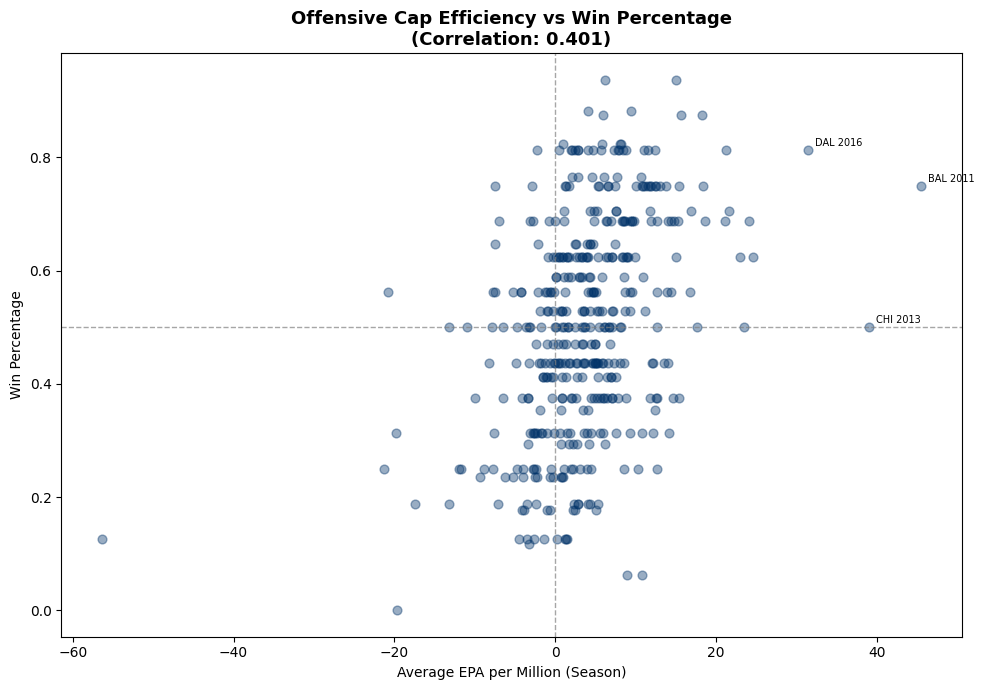

In [7]:
# Pull schedule data for win percentages
import nfl_data_py as nfl

schedules = nfl.import_schedules(range(2011, 2025))
schedules_reg = schedules[schedules['game_type'] == 'REG'].copy()

# Calculate win percentage by team season
home_wins = schedules_reg.groupby(['season', 'home_team']).apply(
    lambda x: (x['result'] > 0).sum()
).reset_index(name='wins')
home_wins.columns = ['season', 'team', 'home_wins']

away_wins = schedules_reg.groupby(['season', 'away_team']).apply(
    lambda x: (x['result'] < 0).sum()
).reset_index(name='wins')
away_wins.columns = ['season', 'team', 'away_wins']

home_games = schedules_reg.groupby(['season', 'home_team']).size().reset_index(name='home_games')
home_games.columns = ['season', 'team', 'home_games']
away_games = schedules_reg.groupby(['season', 'away_team']).size().reset_index(name='away_games')
away_games.columns = ['season', 'team', 'away_games']

win_pct = home_wins.merge(away_wins, on=['season', 'team']).merge(
    home_games, on=['season', 'team']).merge(away_games, on=['season', 'team'])
win_pct['total_wins'] = win_pct['home_wins'] + win_pct['away_wins']
win_pct['total_games'] = win_pct['home_games'] + win_pct['away_games']
win_pct['win_pct'] = win_pct['total_wins'] / win_pct['total_games']

# Merge with team efficiency
team_season_eff = cap_clean.groupby(['team_clean', 'season']).agg(
    avg_epa_per_m=('epa_per_million', 'mean'),
    total_cap=('apy', 'sum')
).reset_index()

team_wins = team_season_eff.merge(
    win_pct[['season', 'team', 'win_pct']],
    left_on=['team_clean', 'season'],
    right_on=['team', 'season'],
    how='inner'
)

corr = team_wins['avg_epa_per_m'].corr(team_wins['win_pct'])
print(f"Correlation between offensive cap efficiency and win %: {corr:.3f}")

plt.figure(figsize=(10, 7))
plt.scatter(team_wins['avg_epa_per_m'], team_wins['win_pct'],
            alpha=0.4, color='#013369', s=40)
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Add team labels for outliers
top_eff = team_wins[team_wins['avg_epa_per_m'] > 25]
for _, row in top_eff.iterrows():
    plt.annotate(f"{row['team_clean']} {int(row['season'])}",
                 (row['avg_epa_per_m'], row['win_pct']),
                 textcoords='offset points', xytext=(5, 3), fontsize=7)

plt.title(f'Offensive Cap Efficiency vs Win Percentage\n(Correlation: {corr:.3f})',
          fontsize=13, fontweight='bold')
plt.xlabel('Average EPA per Million (Season)')
plt.ylabel('Win Percentage')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "cap_efficiency_vs_wins.png"), dpi=150, bbox_inches='tight')
plt.show()

![Cap Efficiency vs Wins](../outputs/figures/cap_efficiency_vs_wins.png)

A correlation of 0.401 between offensive cap efficiency and win percentage is meaningful but not overwhelming — confirming that smart cap spending matters but doesn't guarantee wins. Defense, special teams, coaching, and luck all play significant roles.

**Key observations:**
- **The cloud of points above 0.5 win percentage skews right** — winning teams tend to have positive offensive cap efficiency more often than not
- **DAL 2016 and BAL 2011** are the most extreme outliers — both had exceptional offensive cap efficiency in winning seasons
- **Teams can win with negative cap efficiency** — defense-first teams like the 2011 Ravens show up with high win rates despite modest offensive efficiency
- **The worst cap efficiency seasons cluster at the bottom** — teams spending inefficiently rarely win, confirming the relationship is real even if not perfect

---

### Summary
This notebook ranks all 32 teams by offensive cap efficiency:

1. **Kansas City Chiefs are the most cap-efficient offense** — 9.99 EPA per million, driven by Mahomes and smart surrounding contracts
2. **New York Jets are the least cap-efficient** — negative EPA per million reflecting years of poor QB investment
3. **Offensive cap efficiency correlates at 0.401 with win percentage** — meaningful but not deterministic
4. **The top teams all found efficient QB contracts** — the single biggest driver of team cap efficiency is QB value relative to contract cost
5. **Defense-first teams can win despite low offensive cap efficiency** — cap efficiency is one input to winning, not the only one